# Non-linear CAPM — Minimal Reproducible Notebook

Goal: estimate **beta** (including non-linear curvature) from your merged CRSP + Fama–French file.

**Model:** Polynomial (degree 2) + Ridge regression.

**Outputs:** train/test metrics (R², RMSE, MAE), fit plots, and coefficients for interpretation (linear beta and curvature).

**Instructions:**
1. Make sure your data file exists (parquet or csv).
2. Set `DATA_PATH` below to the correct file (relative or absolute path).
3. Run the notebook top-to-bottom.


In [101]:
# --- 0. Imports
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt

RANDOM_SEED = 42
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)


In [102]:
# --- 1. Point to your merged dataset (edit this if needed)
# Preferred: Parquet for speed; falls back to CSV if parquet not found.
CANDIDATES = [
    Path('../data/crsp_msf_with_factors.parquet'),
    Path('../data/crsp_msf_with_factors.csv'),
]

def load_first_available(paths):
    for p in paths:
        if p.exists():
            print(f'Reading: {p}')
            if p.suffix == '.parquet':
                return pd.read_parquet(p)
            if p.suffix == '.csv':
                return pd.read_csv(p)
    raise FileNotFoundError('No expected data file found. Please set CANDIDATES to the correct path.')

df = load_first_available(CANDIDATES)
print('shape:', df.shape)
df.head()


Reading: ../data/crsp_msf_with_factors.parquet
shape: (1288566, 20)


,permno,shrcd,exchcd,siccd,dlret,prc,vol,ret,shrout,ret_adj,market_equity,turnover,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,date
0,10001,11.0,3.0,4920.0,NaN,8.12500,403.0,-0.044118,2450.0,-0.044118,19906.25,0.164490,-4.74,4.21,-1.12,-6.15,4.56,0.41,1.86,2000-01
1,10001,11.0,3.0,4920.0,NaN,8.25000,222.0,0.015385,2450.0,0.015385,20212.50,0.090612,2.45,18.46,-9.77,-18.95,-1.13,0.43,18.02,2000-02
2,10001,11.0,3.0,4920.0,NaN,-8.00000,723.0,-0.015758,2464.0,-0.015758,19712.00,0.293425,5.21,-15.54,8.50,11.65,-1.20,0.47,-6.85,2000-03
3,10001,11.0,3.0,4920.0,NaN,-8.09375,263.0,0.011719,2464.0,0.011719,19943.00,0.106737,-6.35,-4.75,6.45,8.07,5.63,0.46,-8.60,2000-04
4,10001,11.0,3.0,4920.0,NaN,-7.90625,221.0,-0.023166,2464.0,-0.023166,19481.00,0.089692,-4.39,-3.86,4.59,4.05,1.47,0.50,-8.99,2000-05


In [103]:
# --- 2. Select essential columns and compute excess return
required = ['ret', 'Mkt-RF', 'RF']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns in data: {missing}. Available: {list(df.columns)[:30]} ...')

d = df[required].dropna().copy()
d['excess_ret'] = d['ret'] - d['RF']

# Use only the first 500 rows for a tiny, fast experiment
# d_small = d.iloc[:500].copy()
# use all data 
d_small = d.copy()
print('Working sample shape:', d_small.shape)
d_small.describe()


Working sample shape: (1288566, 4)


,ret,Mkt-RF,RF,excess_ret
count,1.288566e+06,1.288566e+06,1.288566e+06,1.288566e+06
mean,9.058612e-03,4.507984e-01,1.630493e-01,-1.539907e-01
std,2.048117e-01,4.634331e+00,1.680898e-01,2.680028e-01
min,-9.956900e-01,-1.720000e+01,0.000000e+00,-1.471538e+00
25%,-7.070200e-02,-2.150000e+00,1.000000e-02,-3.210830e-01
50%,1.537000e-03,1.100000e+00,1.100000e-01,-1.223065e-01
75%,7.141475e-02,3.240000e+00,3.100000e-01,0.000000e+00
max,2.658383e+01,1.358000e+01,5.600000e-01,2.614383e+01


In [104]:
# --- 3. Train/test split (reproducible)
X = d_small[['Mkt-RF']]
y = d_small['excess_ret']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.001, random_state=RANDOM_SEED
)
X_train.shape, X_test.shape


((1287277, 1), (1289, 1))

In [105]:
# --- 4. Build Non-linear CAPM (Polynomial degree=2 + Ridge)
pipe_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0, random_state=42)),
])

pipe_poly.fit(X_train, y_train)
print('Fitted non-linear CAPM (Poly2 + Ridge).')


Fitted non-linear CAPM (Poly2 + Ridge).


In [106]:
# --- 5. Evaluate model
y_pred_tr = pipe_poly.predict(X_train)
y_pred_te = pipe_poly.predict(X_test)

r2_tr = r2_score(y_train, y_pred_tr)
r2_te = r2_score(y_test, y_pred_te)

# Avoid squared kwarg for maximal compatibility
rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred_te))
mae_tr  = mean_absolute_error(y_train, y_pred_tr)
mae_te  = mean_absolute_error(y_test,  y_pred_te)

print(f'Train  → R²={r2_tr:.4f}, RMSE={rmse_tr:.6f}, MAE={mae_tr:.6f}')
print(f'Test   → R²={r2_te:.4f}, RMSE={rmse_te:.6f}, MAE={mae_te:.6f}')


Train  → R²=0.0760, RMSE=0.257602, MAE=0.183047
Test   → R²=0.0835, RMSE=0.270721, MAE=0.189351


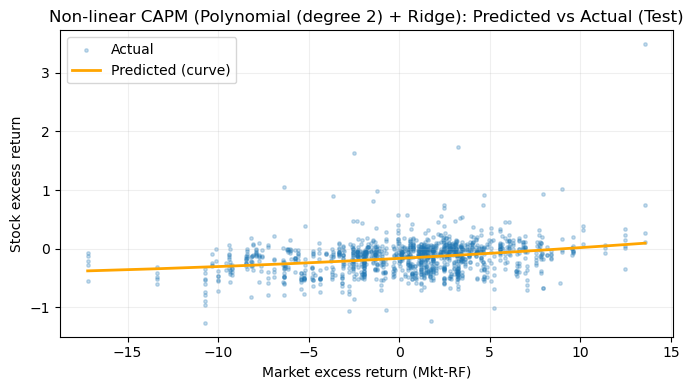

In [107]:
# --- 6. Improved plot: Non-linear CAPM (Poly2 + Ridge) ---
import pandas as pd
import matplotlib.pyplot as plt

# Build dataframe for smoother plotting
plot_df = pd.DataFrame({
    'Mkt_RF': X_test['Mkt-RF'].values,
    'Actual': y_test.values,
    'Predicted': y_pred_te
}).sort_values('Mkt_RF')


plt.figure(figsize=(7,4))
plt.scatter(plot_df['Mkt_RF'], plot_df['Actual'], s=6, alpha=0.25, label='Actual')
plt.plot(plot_df['Mkt_RF'], plot_df['Predicted'], color='orange', lw=2.0, label='Predicted (curve)')
plt.title('Non-linear CAPM (Polynomial (degree 2) + Ridge): Predicted vs Actual (Test)')
plt.xlabel('Market excess return (Mkt-RF)')
plt.ylabel('Stock excess return')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [108]:
df['Excess_Return'] = df['ret_adj'] - df['RF']   # or ret - RF
df[['Excess_Return', 'Mkt-RF']].corr()

,Excess_Return,Mkt-RF
Excess_Return,1.000000,0.274354
Mkt-RF,0.274354,1.000000


In [109]:
# --- 7. Coefficient interpretation (beta and curvature)
ridge_model = pipe_poly.named_steps['ridge']
poly_model  = pipe_poly.named_steps['poly']
feature_names = poly_model.get_feature_names_out(['Mkt-RF'])

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': ridge_model.coef_,
})
display(coef_table)

print('\nInterpretation:')
print(" - 'Mkt-RF'  → linear beta (first-order sensitivity)")
print(" - 'Mkt-RF^2'→ curvature (convexity/concavity); sign shows shape of non-linearity")


,feature,coefficient
0,Mkt-RF,0.075731
1,Mkt-RF^2,0.004703



Interpretation:
 - 'Mkt-RF'  → linear beta (first-order sensitivity)
 - 'Mkt-RF^2'→ curvature (convexity/concavity); sign shows shape of non-linearity


## Notes
- If you prefer **pure linear CAPM** for comparison, change the pipeline to `StandardScaler() + LinearRegression()`.
- To test stability, change `RANDOM_SEED` and re-run.
- To scale up beyond the first 500 rows, increase the slice in step 2 (mind runtime).


In [110]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred_te)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_te))
print(f"Test R²: {r2:.4f}, RMSE: {rmse:.4f}")

Test R²: 0.0835, RMSE: 0.2707


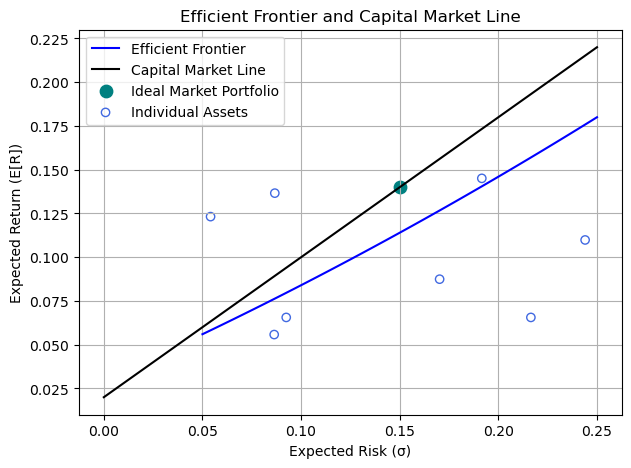

In [111]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1. Simulated data ---
np.random.seed(42)
n_assets = 8
expected_returns = np.random.uniform(0.05, 0.15, n_assets)   # expected return
risks = np.random.uniform(0.05, 0.25, n_assets)               # standard deviation

# --- Step 2. Efficient frontier curve (toy quadratic) ---
frontier_risk = np.linspace(0.05, 0.25, 100)
frontier_return = 0.03 + 0.5*frontier_risk + 0.4*(frontier_risk**2)

# --- Step 3. Capital Market Line (CML) ---
risk_free = 0.02
market_risk, market_return = 0.15, 0.14
cml_risk = np.linspace(0, 0.25, 100)
cml_return = risk_free + (market_return - risk_free) / market_risk * cml_risk

# --- Step 4. Plot ---
plt.figure(figsize=(7,5))
plt.plot(frontier_risk, frontier_return, 'b', label='Efficient Frontier')
plt.plot(cml_risk, cml_return, 'k', label='Capital Market Line')
plt.scatter(market_risk, market_return, color='teal', s=80, label='Ideal Market Portfolio')
plt.scatter(risks, expected_returns, facecolors='none', edgecolors='royalblue', label='Individual Assets')

plt.xlabel('Expected Risk (σ)')
plt.ylabel('Expected Return (E[R])')
plt.title('Efficient Frontier and Capital Market Line')
plt.legend()
plt.grid(True)
plt.show()

df_test shape: (1289, 6)
              ret  Mkt-RF    RF  excess_ret    y_true    y_pred
1204458 -0.040936   -0.87  0.27   -0.310936 -0.310936 -0.179904
1229163 -0.037867    2.95  0.00   -0.037867 -0.037867 -0.116494
1108929 -0.033820    2.84  0.43   -0.463820 -0.463820 -0.118410
33820    0.038462    3.25  0.54   -0.501538 -0.501538 -0.111244
1137377 -0.015748    4.53  0.15   -0.165748 -0.165748 -0.088399


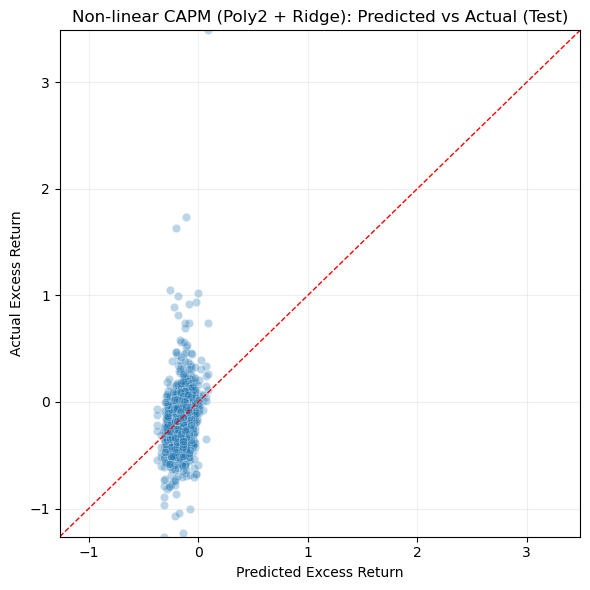

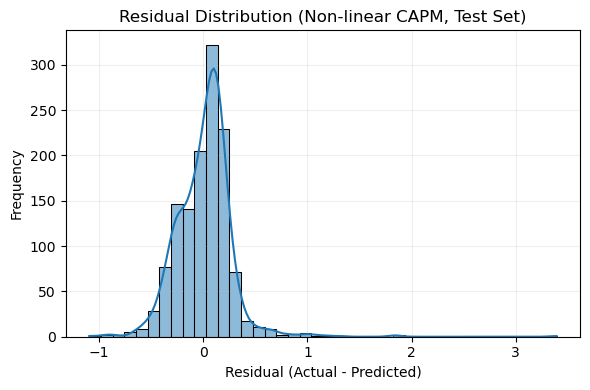

Residual mean: 0.008883641042512675
Residual std: 0.2706797965796639


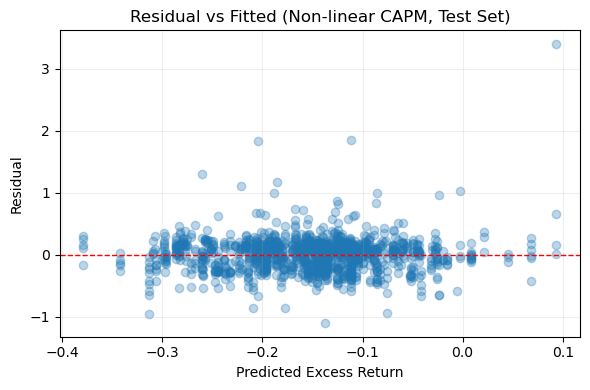

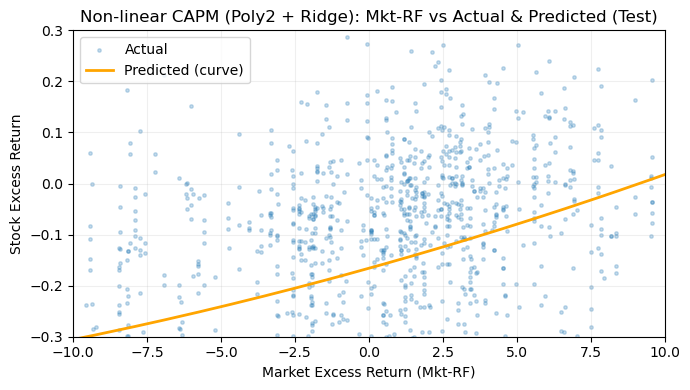

Test R² = 0.0835
Test RMSE = 0.270721
Test MAE = 0.189351


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# ---------------------------------------------------------------------
# Build df_test aligned with your existing setup (d_small, y_test, y_pred_te)
# ---------------------------------------------------------------------
df_test = d_small.loc[y_test.index].copy()   # d_small has ret, Mkt-RF, RF, excess_ret
df_test["y_true"] = y_test                   # actual excess return
df_test["y_pred"] = y_pred_te                # predicted excess return

print("df_test shape:", df_test.shape)
print(df_test.head())

# ---------------------------------------------------------------------
# 1. Scatter Plot: Predicted vs Actual (Test Set)
# ---------------------------------------------------------------------
plt.figure(figsize=(6,6))
sns.scatterplot(x=df_test["y_pred"], y=df_test["y_true"], alpha=0.3)
plt.xlabel("Predicted Excess Return")
plt.ylabel("Actual Excess Return")
plt.title("Non-linear CAPM (Poly2 + Ridge): Predicted vs Actual (Test)")
# 45-degree line
lims = [
    min(df_test["y_true"].min(), df_test["y_pred"].min()),
    max(df_test["y_true"].max(), df_test["y_pred"].max())
]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2. Residual Distribution
# ---------------------------------------------------------------------
residuals = df_test["y_true"] - df_test["y_pred"]

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=40)
plt.title("Residual Distribution (Non-linear CAPM, Test Set)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Basic residual stats
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())

# ---------------------------------------------------------------------
# 3. Residual vs Fitted (Check for patterns / heteroskedasticity)
# ---------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.scatter(df_test["y_pred"], residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Excess Return")
plt.ylabel("Residual")
plt.title("Residual vs Fitted (Non-linear CAPM, Test Set)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4. Mkt-RF vs Actual & Predicted (Smoothed Curve)
#    This extends your existing plot with clearer structure
# ---------------------------------------------------------------------
plot_df = df_test[["Mkt-RF", "y_true", "y_pred"]].copy()
plot_df = plot_df.rename(columns={"y_true": "Actual", "y_pred": "Predicted"})
plot_df = plot_df.sort_values("Mkt-RF")

plt.figure(figsize=(7,4))
# scatter for actual points
plt.scatter(plot_df["Mkt-RF"], plot_df["Actual"], s=6, alpha=0.25, label="Actual")
# smooth line for predicted
plt.plot(plot_df["Mkt-RF"], plot_df["Predicted"], color="orange", lw=2.0, label="Predicted (curve)")
plt.title("Non-linear CAPM (Poly2 + Ridge): Mkt-RF vs Actual & Predicted (Test)")
plt.xlabel("Market Excess Return (Mkt-RF)")
plt.ylabel("Stock Excess Return")
plt.ylim(-0.3, 0.3) 
plt.xlim(-10,10)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# (Optional) Reprint test metrics for convenience
# ---------------------------------------------------------------------
r2_te = r2_score(y_test, y_pred_te)
rmse_te = np.sqrt(((y_test - y_pred_te)**2).mean())
mae_te = np.abs(y_test - y_pred_te).mean()

print(f"Test R² = {r2_te:.4f}")
print(f"Test RMSE = {rmse_te:.6f}")
print(f"Test MAE = {mae_te:.6f}")